## Importar bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Ler as bases de dados

In [3]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocations = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
#order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

## Verifica se os datasets foram criados   

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    #"order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


## Pergunta Norteadora
#### “Quais fatores mais influenciam a satisfação do cliente no e-commerce e como a empresa pode atuar sobre eles para melhorar a experiência?”

Para explorar a pergunta norteadora vamos investigar 5 variáveis:

- Categoria do Produto: [product_category_name], disponível na base olist_products_dataset
- Dias de atraso na entrega: Vamos criar a variável [dias_atraso_entrega] =  max(0,[order_delivered_customer_date] - [order_estimated_delivery_date]), disponíveis em olist_orders_dataset
- Valor total da compra: que vai ser a soma dos itens comprados [preco_tota_item] = [price] + [freight_value]obs. Optamos por não utilizar o valor total da compra para manter a granularidade da tabela no nível de item
- Valor do frete: [frete_total] = order_items.groupby("order_id")["freight_value"].sum() disponível na olist_order_items_dataset
- Região (Cidade e Estado)

Pretendemos descobrir o impacto que essas variáveis possuem na dimenssão experiência:

- Experiência do cliente: Vamos considerar com base na avaliação [review_score], disponível na base olist_order_reviews_dataset


No final da análise pretendemos avaliar o impacto que as 5 variáveis explicativas possuem na variável resultado, com isso imaginar soluções e fatores operacionais que devem ser priorizados pelos vendedores para maximizar a satisfação dos clientes.


### Preparação dos dados

A Base desejada tem o formato:

        "order_id",
        "order_item_id",
        "product_id",
        "customer_id" - olist_customers_dataset
        "seller_id",
        "product_category_name",
        "dias_atraso_entrega",
        "preco_total_item",
        "price",
        "freight_value",
        "review_score",
        "customer_city" - olist_customers_dataset
        "customer_state" - olist_customers_dataset

        

Onde um mesmo order_id terá n linhas dependendo da quantidade de itens

## Preparação dos dados (ETL)

In [5]:
# Criando a variável dias_atraso_entrega no df orders

# Tranformando as colunas de data para o formato datetime

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

# Criando a variável dias_atraso_entrega

orders["dias_atraso_entrega"] = (
    # Variável de atraso de entrega é a diferença entre a data de entrega real e a data de entrega estimada
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

# Atraso não pode ser negativo, então usamos clip para definir o valor mínimo como 0
orders["dias_atraso_entrega"] = orders["dias_atraso_entrega"].clip(lower=0) 


In [6]:
# Juntando pedidos com itens

df = order_items.merge(
    orders[["order_id", "customer_id", "dias_atraso_entrega"]],
    on="order_id",
    how="left"
)

In [7]:
# Adicionando categoria dos itens

df = df.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [8]:
# Testando se existem valores duplicados no campo order_id da tabela de avaliações

order_reviews["order_id"].duplicated().sum()

# O resultado positivo indica que existem avaliações duplicadas para um mesmo pedido, portanto precisamos tratar essas avaliações para evitar distorções nas análises.


np.int64(551)

In [9]:
# Adicionando as avaliações dos pedidos ao df

# Mantem apenas a última avaliação para cada pedido, caso haja mais de uma avaliação para um mesmo pedido. Isso é feito usando o método drop_duplicates com o parâmetro keep='last'.
reviews_unique = order_reviews.drop_duplicates(subset="order_id", keep='last').reset_index(drop=True)

# Adicionando a média das avaliações por pedido ao df

df = df.merge(
    reviews_unique[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [10]:
# Criando uma coluna de preço total do item (que é a soma do preço com o frete)
df["preco_total_item"] = df["price"] + df["freight_value"]

In [11]:
# buscando o customer_unique_id para identificar os clientes únicos e suas respectivas cidades e estados

df = df.merge(
    customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

In [12]:
# Selecionando colunas relevantes para análise

df_final = df[
    [
        "order_id",
        "order_item_id",
        "product_id",
        "customer_id",
        "customer_unique_id",
        "seller_id",
        "product_category_name",
        "dias_atraso_entrega",
        "preco_total_item",
        "price",
        "freight_value",
        "review_score",
        "customer_city",
        "customer_state"
    ]
]

In [13]:
# Apresentando as primeiras linhas do df_final para verificar se os dados foram integrados corretamente

df_final.head()

,order_id,order_item_id,product_id,customer_id,customer_unique_id,seller_id,product_category_name,dias_atraso_entrega,preco_total_item,price,freight_value,review_score,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,48436dade18ac8b2bce089ec2a041202,cool_stuff,0.0,72.19,58.90,13.29,5.0,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,0.0,259.83,239.90,19.93,4.0,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,0.0,216.87,199.00,17.87,5.0,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,9d7a1d34a5052409006425275ba1c2b4,perfumaria,0.0,25.78,12.99,12.79,4.0,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,0.0,218.04,199.90,18.14,5.0,varzea paulista,SP


### Entendendo a variável de resultado

In [14]:
df_final["review_score"].value_counts(normalize=True)

review_score
5.0    0.565295
4.0    0.189789
1.0    0.126616
3.0    0.083879
2.0    0.034420
Name: proportion, dtype: float64

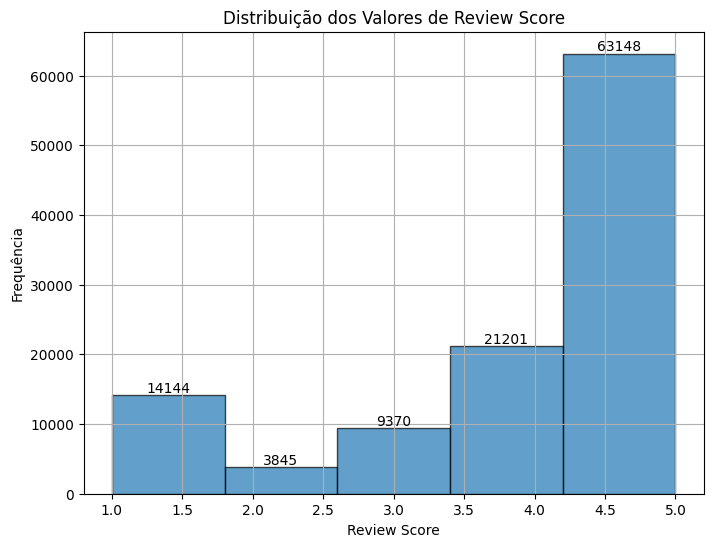

In [15]:
# Histograma da distribuição dos valores de review_score

plt.figure(figsize=(8, 6))

counts, bins, patches = plt.hist(
    df_final['review_score'].dropna(),
    bins=5,
    edgecolor='black',
    alpha=0.7
)

# Adiciona rótulos de frequência em cada barra
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição dos Valores de Review Score')
plt.xlabel('Review Score')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

## Começando as análises

#### Categoria do Produto

In [16]:
# Avaliação média por categoria de produto

avaliacao_por_categoria = (
    df_final
    .groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

avaliacao_por_categoria.head(120)

product_category_name
cds_dvds_musicais                                4.642857
fashion_roupa_infanto_juvenil                    4.500000
livros_interesse_geral                           4.446266
construcao_ferramentas_ferramentas               4.444444
flores                                           4.419355
                                                   ...   
moveis_escritorio                                3.485987
pc_gamer                                         3.333333
portateis_cozinha_e_preparadores_de_alimentos    3.266667
fraldas_higiene                                  3.256410
seguros_e_servicos                               2.500000
Name: review_score, Length: 73, dtype: float64

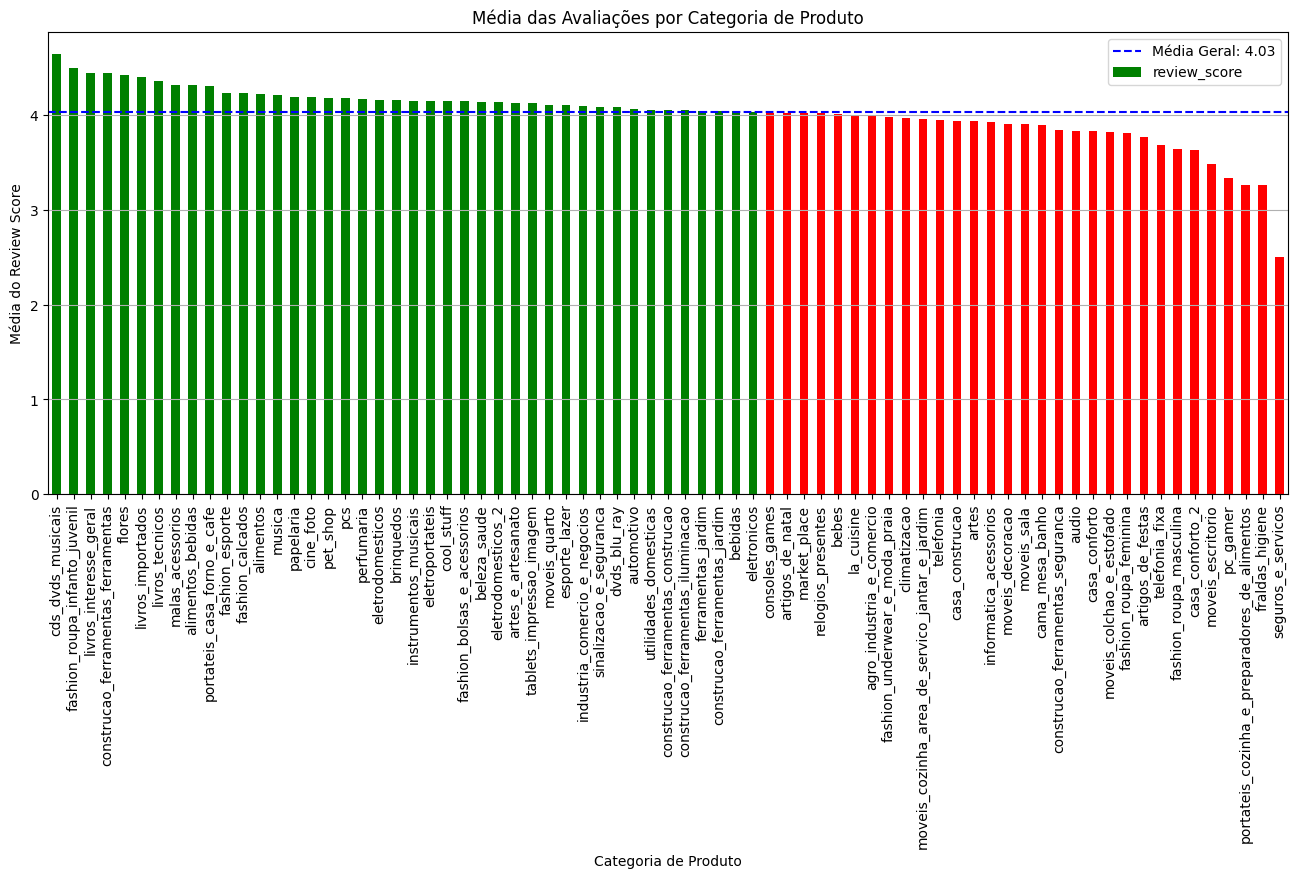

In [17]:
# Gráfico de barras com a média das avaliações por categoria de produto e uma linha de referência para a média geral. Categorias acima da média geral tem as barras em verde, enquanto as categorias abaixo da média geral tem as barras em vermelho.

media_geral = df_final["review_score"].mean()
cores = ['green' if media >= media_geral else 'red' for media in avaliacao_por_categoria]
plt.figure(figsize=(16, 6))
avaliacao_por_categoria.plot(kind='bar', color=cores)
plt.axhline(media_geral, color='blue', linestyle='--', label=f'Média Geral: {media_geral:.2f}')
plt.title('Média das Avaliações por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Média do Review Score')
plt.legend()
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()



### Dias de atraso na entrega

In [18]:
# Retira atrasos maiores que 30 dias para evitar distorção na análise de avaliação por atraso
df_atraso_filtrado = df_final[
    df_final["dias_atraso_entrega"] <= 30
]

# Calcula a avaliação média por dias de atraso
atraso_vs_review = (
    df_atraso_filtrado
    .groupby("dias_atraso_entrega")["review_score"]
    .mean()
    .reset_index()
)

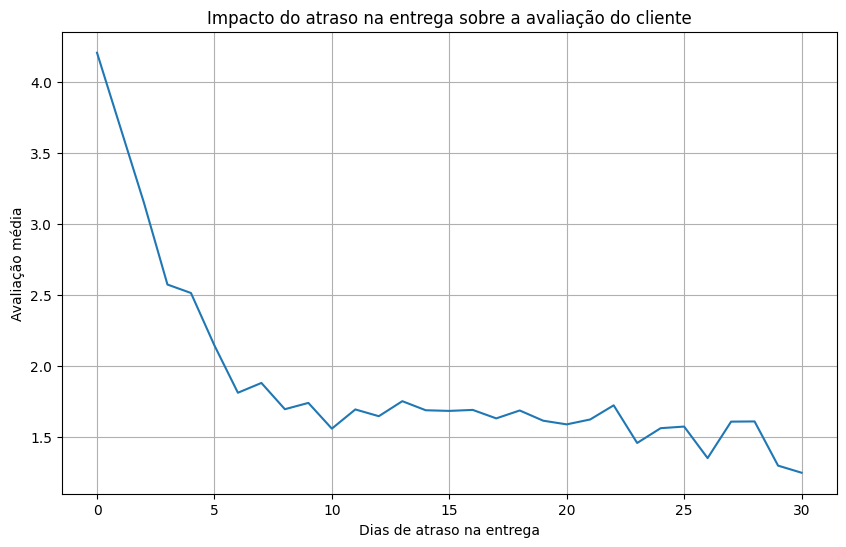

In [19]:
# Gráfico de linha da avaliação média por dias de atraso

plt.figure(figsize=(10,6))

plt.plot(
    atraso_vs_review["dias_atraso_entrega"],
    atraso_vs_review["review_score"]
)

plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Avaliação média")
plt.title("Impacto do atraso na entrega sobre a avaliação do cliente")
plt.grid(True)

plt.show()

In [20]:
# R² para avaliar a relação entre dias de atraso e avaliação

from sklearn.linear_model import LinearRegression

X = atraso_vs_review[["dias_atraso_entrega"]]
y = atraso_vs_review["review_score"]

modelo = LinearRegression()
modelo.fit(X, y)

r2 = modelo.score(X, y)
r2

0.5395106483238816

In [21]:
# Comparação da avaliação média para entregas no prazo vs entregas com atraso

print("Avaliação média para entregas no prazo:", df_final[df_final["dias_atraso_entrega"] == 0]["review_score"].mean())
print("Avaliação média para entregas com atraso:", df_final[df_final["dias_atraso_entrega"] > 0]["review_score"].mean())


Avaliação média para entregas no prazo: 4.207772400645256
Avaliação média para entregas com atraso: 2.257622811970638


A análise da relação entre o atraso na entrega e a avaliação média dos pedidos evidenciou uma forte correlação negativa. Observou-se que mesmo pequenos atrasos de 2 a 3 dias resultam em quedas expressivas na avaliação média, que passa de valores superiores a 4 para níveis próximos a 2. Após aproximadamente uma semana de atraso, a avaliação se estabiliza em patamares baixos, indicando que o cliente já percebeu a experiência como insatisfatória.

### Valor total da compra

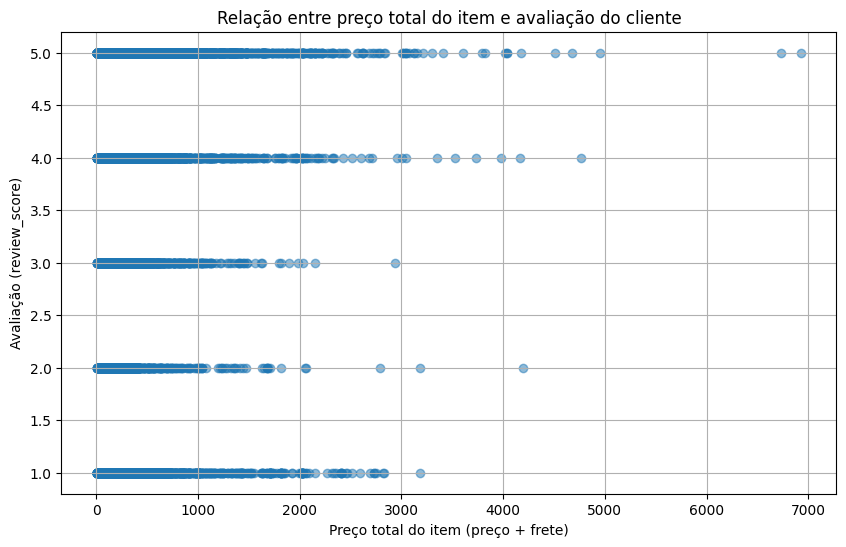

In [22]:
# Gráfico de dispensção das avaliações vs o valor total do item (preço + frete)

plt.figure(figsize=(10,6))
plt.scatter(df_final["preco_total_item"], df_final["review_score"], alpha=0.5)
plt.xlabel("Preço total do item (preço + frete)")
plt.ylabel("Avaliação (review_score)")
plt.title("Relação entre preço total do item e avaliação do cliente")
plt.grid(True)
plt.show()


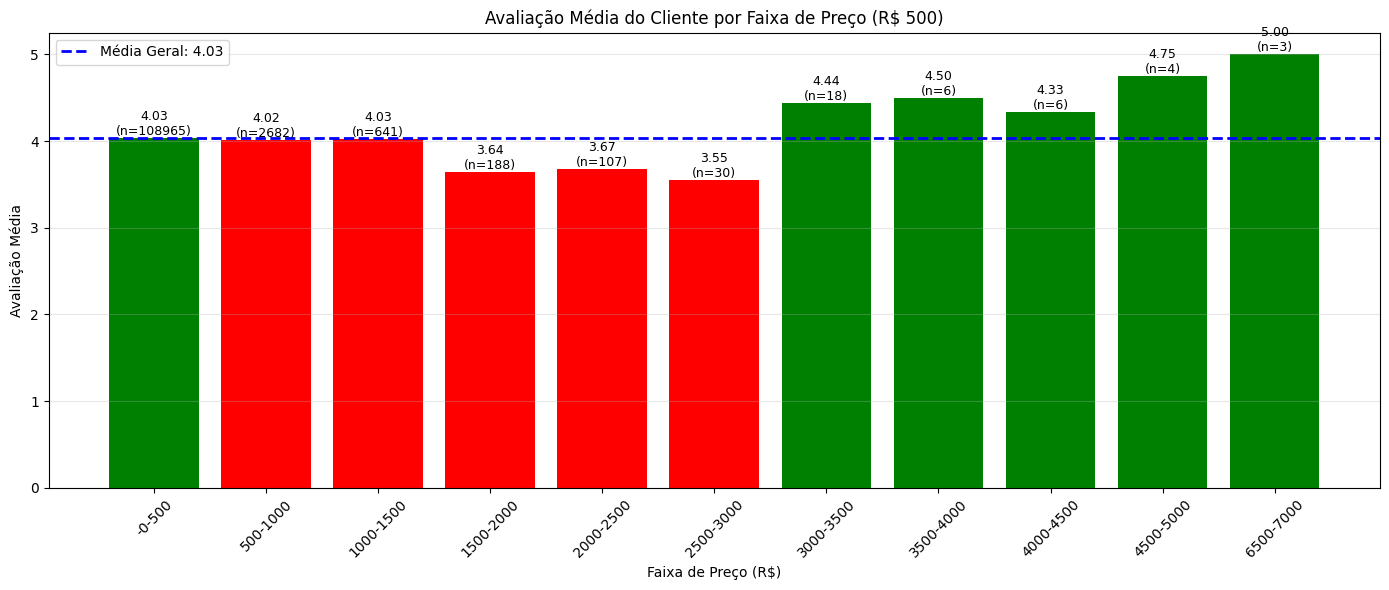

In [ ]:
# Histograma de 500 em 500 reais com avaliação média no eixo y

# Criando bins de 500 em 500 reais
bins = list(range(0, int(df_final["preco_total_item"].max()) + 500, 500))

# Criando uma coluna com o bin de preço
df_final["faixa_preco"] = pd.cut(df_final["preco_total_item"], bins=bins, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa = (
    df_final
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa)), avaliacao_por_faixa["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa["review_score"], avaliacao_por_faixa["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 500)")
plt.xticks(range(len(avaliacao_por_faixa)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_final = df_final.drop("faixa_preco", axis=1)

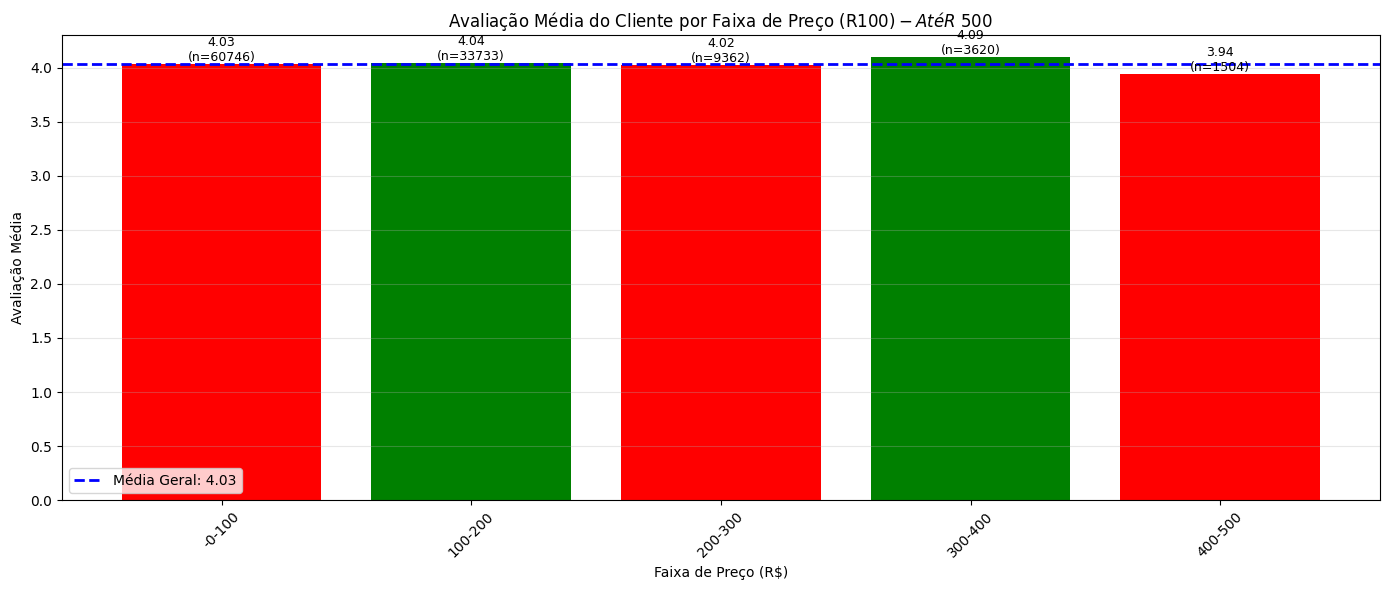

In [34]:
# Mesmo gráfico anterior, mas apenas com pedidos de até 500 reais e bins de 100 em 100

# Filtrando dados até 500 reais
df_filtrado = df_final[df_final["preco_total_item"] <= 500]

# Criando bins de 100 em 100 reais
bins = list(range(0, 501, 100))

# Criando uma coluna com o bin de preço
df_filtrado["faixa_preco"] = pd.cut(df_filtrado["preco_total_item"], bins=bins, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa_filtrado = (
    df_filtrado
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa_filtrado["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa_filtrado)), avaliacao_por_faixa_filtrado["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa_filtrado["review_score"], avaliacao_por_faixa_filtrado["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 100) - Até R$ 500")
plt.xticks(range(len(avaliacao_por_faixa_filtrado)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa_filtrado["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_filtrado = df_filtrado.drop("faixa_preco", axis=1)

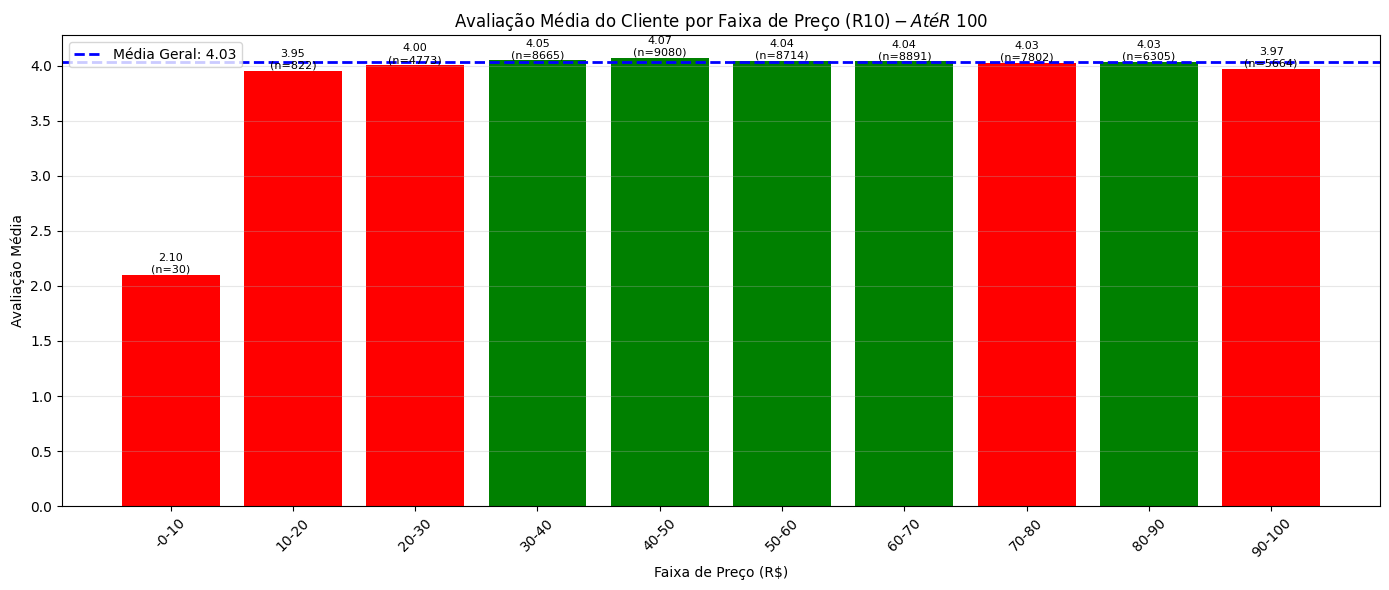

In [38]:
# Gráfico com compras até 100 reais e bins de 10 em 10

# Filtrando dados até 100 reais
df_filtrado_100 = df_final[df_final["preco_total_item"] <= 100]

# Criando bins de 10 em 10 reais
bins_10 = list(range(0, 101, 10))

# Criando uma coluna com o bin de preço
df_filtrado_100["faixa_preco"] = pd.cut(df_filtrado_100["preco_total_item"], bins=bins_10, include_lowest=True)

# Agrupando por faixa de preço e calculando a média das avaliações e total de compras
avaliacao_por_faixa_100 = (
    df_filtrado_100
    .groupby("faixa_preco", observed=True)
    .agg({
        "review_score": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "total_compras"})
    .reset_index()
)

# Calculando a avaliação média geral
media_geral = df_final["review_score"].mean()

# Definindo cores: verde se acima da média, vermelho se abaixo
cores = ['green' if avaliacao >= media_geral else 'red' for avaliacao in avaliacao_por_faixa_100["review_score"]]

# Gráfico de barras
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(avaliacao_por_faixa_100)), avaliacao_por_faixa_100["review_score"], color=cores)

# Adicionando rótulos com avaliação média e total de compras
for i, (bar, avg, count) in enumerate(zip(bars, avaliacao_por_faixa_100["review_score"], avaliacao_por_faixa_100["total_compras"])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{avg:.2f}\n(n={count})', ha='center', va='bottom', fontsize=8)

plt.axhline(media_geral, color='blue', linestyle='--', linewidth=2, label=f'Média Geral: {media_geral:.2f}')
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Avaliação Média")
plt.title("Avaliação Média do Cliente por Faixa de Preço (R$ 10) - Até R$ 100")
plt.xticks(range(len(avaliacao_por_faixa_100)), [f"{interval.left:.0f}-{interval.right:.0f}" for interval in avaliacao_por_faixa_100["faixa_preco"]], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Removendo a coluna temporária
df_filtrado_100 = df_filtrado_100.drop("faixa_preco", axis=1)

### Valor do frete

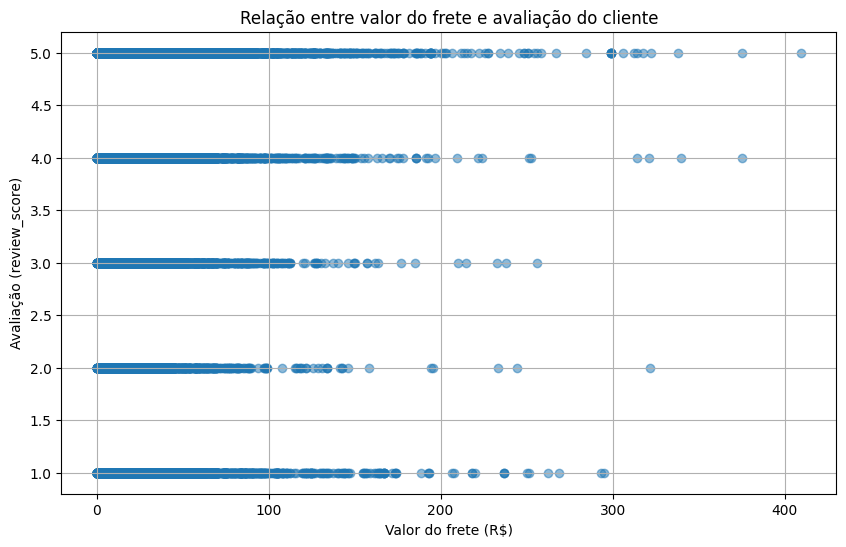

In [40]:
# Grafico de dispersão do valor do frete vs avaliação

plt.figure(figsize=(10,6))
plt.scatter(df_final["freight_value"], df_final["review_score"], alpha=0.5)
plt.xlabel("Valor do frete (R$)")
plt.ylabel("Avaliação (review_score)")
plt.title("Relação entre valor do frete e avaliação do cliente")
plt.grid(True)
plt.show()


### Região (Cidade e Estado)

## Análise final

### Analisando se total de vendas do vendedor pode ser impactado pela avaliação média

In [25]:
resumo_vendedores = (
    df_final
    .groupby("seller_id")
    .agg({
        "order_id": "nunique",      # total de vendas (pedidos)
        "review_score": "mean"      # média de avaliação
    })
    .rename(columns={
        "order_id": "total_vendas",
        "review_score": "avaliacao_media"
    })
    .sort_values("total_vendas", ascending=False)
)

resumo_vendedores.head(10)

,total_vendas,avaliacao_media
seller_id,,
6560211a19b47992c3666cc44a7e94c0,1854,3.907646
4a3ca9315b744ce9f8e9374361493884,1806,3.800204
cc419e0650a3c5ba77189a1882b7556a,1706,4.069044
1f50f920176fa81dab994f9023523100,1404,3.988560
da8622b14eb17ae2831f4ac5b9dab84a,1314,4.059547
955fee9216a65b617aa5c0531780ce60,1287,4.050437
7a67c85e85bb2ce8582c35f2203ad736,1160,4.233219
ea8482cd71df3c1969d7b9473ff13abc,1146,3.952341
4869f7a5dfa277a7dca6462dcf3b52b2,1132,4.122822


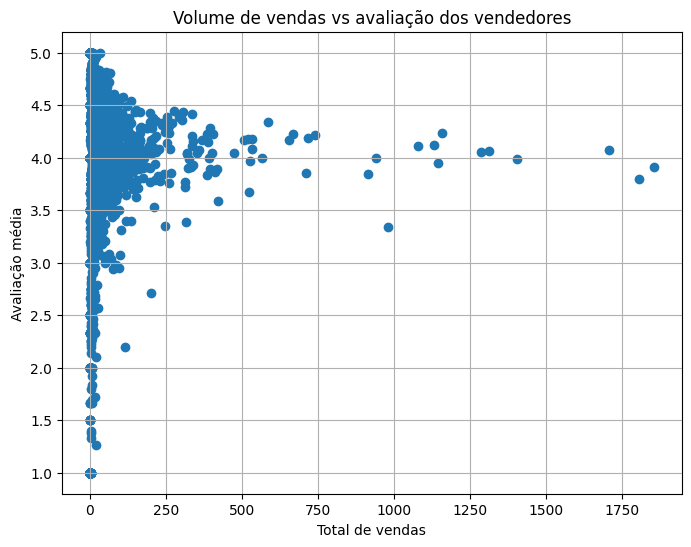

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    resumo_vendedores["total_vendas"],
    resumo_vendedores["avaliacao_media"]
)

plt.xlabel("Total de vendas")
plt.ylabel("Avaliação média")
plt.title("Volume de vendas vs avaliação dos vendedores")
plt.grid(True)
plt.show()

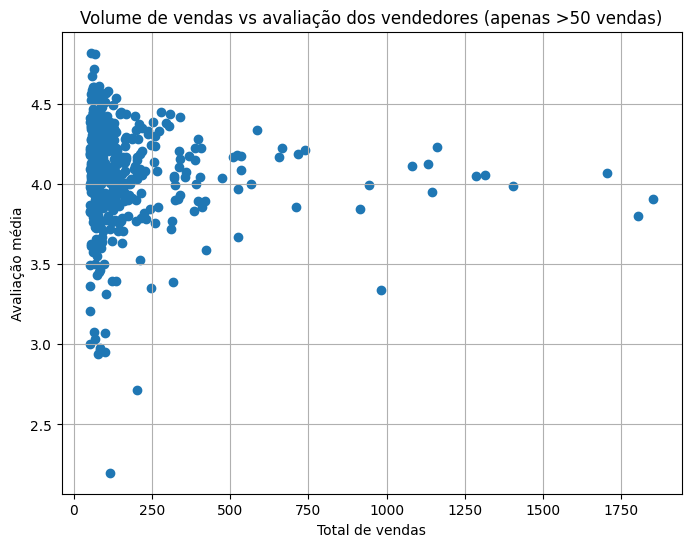

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    resumo_vendedores[resumo_vendedores["total_vendas"] > 50]["total_vendas"],
    resumo_vendedores[resumo_vendedores["total_vendas"] > 50]["avaliacao_media"]
)

plt.xlabel("Total de vendas")
plt.ylabel("Avaliação média")
plt.title("Volume de vendas vs avaliação dos vendedores (apenas >50 vendas)")
plt.grid(True)

plt.show()

In [28]:
pedidos_atrasados = (
    df_final[df_final["dias_atraso_entrega"] > 0]["order_id"]
    .nunique()
)

pedidos_atrasados


6535